In [4]:
!pip install wordcloud

In [5]:
from wordcloud import WordCloud

In [8]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gagan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gagan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
df = pd.read_csv("C:\\Users\\gagan\\Downloads\\amazonreviews.tsv", sep="\t")

print(df.shape)
df.head()

(10000, 2)


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [10]:
#basic information
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None

Missing Values:
label     0
review    0
dtype: int64

Duplicate Rows:
0


In [11]:
#data cleaning
df.drop_duplicates(inplace=True)

df.dropna(subset=['review'], inplace=True)

print(df.shape)

(10000, 2)


In [13]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [14]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gagan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gagan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gagan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

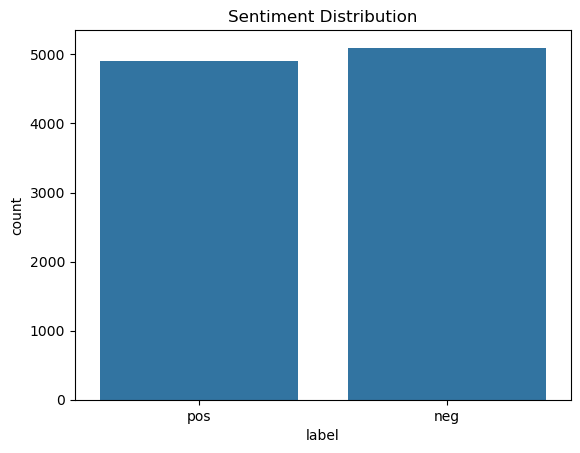

label
neg    5097
pos    4903
Name: count, dtype: int64


In [16]:
sns.countplot(
    x='label',
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

print(df['label'].value_counts())

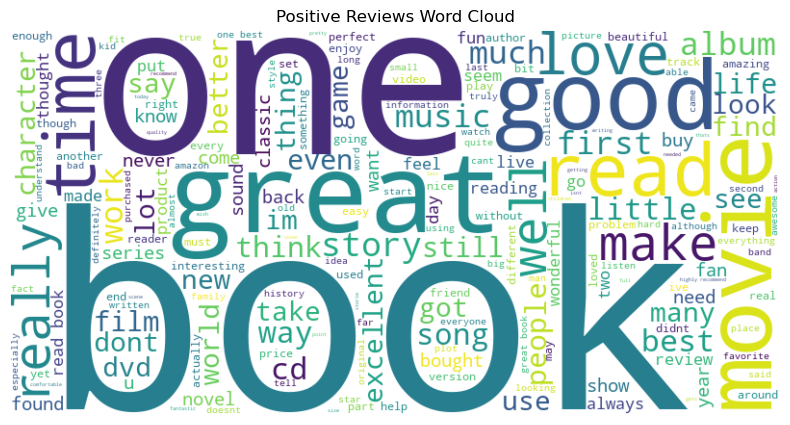

In [17]:
#positive reviews word cloud
positive_text = " ".join(
    df[df['label']=='pos']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

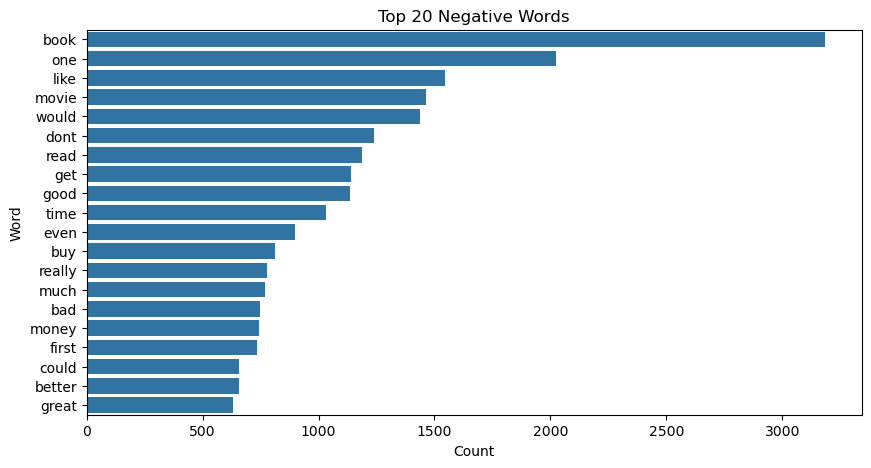

In [18]:
negative_words = " ".join(
    df[df['label']=='neg']['clean_review']
).split()

negative_counts = Counter(negative_words)

top_negative = pd.DataFrame(
    negative_counts.most_common(20),
    columns=['Word','Count']
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_negative,
    x='Count',
    y='Word'
)

plt.title("Top 20 Negative Words")
plt.show()

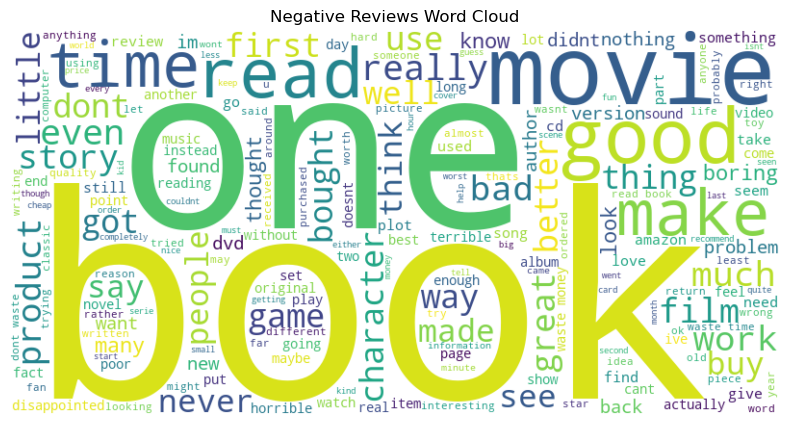

In [19]:
#negative reviewa word cloud
negative_text = " ".join(
    df[df['label']=='neg']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

      Word  Count
0     book   3313
1    great   2087
2      one   1835
3     good   1635
4     read   1553
5     like   1268
6    movie   1085
7    would    943
8     love    902
9     time    871
10    well    854
11  really    827
12    best    801
13     get    793
14   story    713
15   first    708
16    much    650
17      cd    581
18   music    559
19    also    557


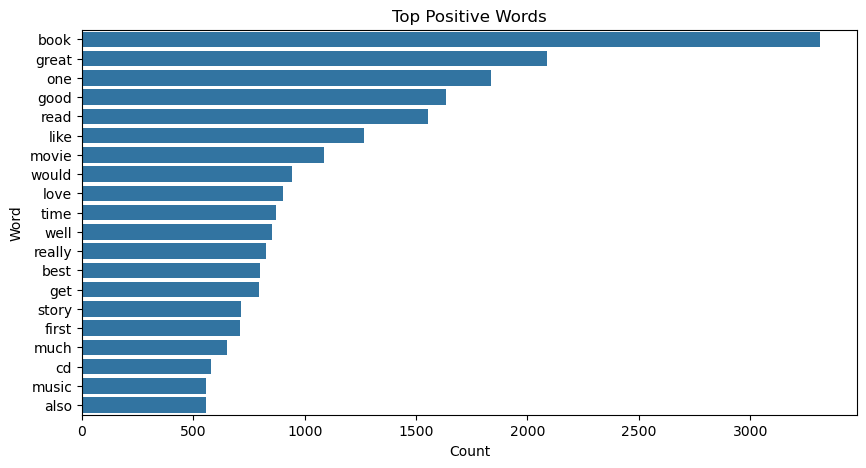

In [20]:
#most common positive words
from collections import Counter

positive_words = " ".join(
    df[df['label']=='pos']['clean_review']
).split()

positive_counts = Counter(positive_words)

top_positive = pd.DataFrame(
    positive_counts.most_common(20),
    columns=['Word','Count']
)

print(top_positive)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Count',
    y='Word',
    data=top_positive
)

plt.title("Top Positive Words")
plt.show()

      Word  Count
0     book   3313
1    great   2087
2      one   1835
3     good   1635
4     read   1553
5     like   1268
6    movie   1085
7    would    943
8     love    902
9     time    871
10    well    854
11  really    827
12    best    801
13     get    793
14   story    713
15   first    708
16    much    650
17      cd    581
18   music    559
19    also    557


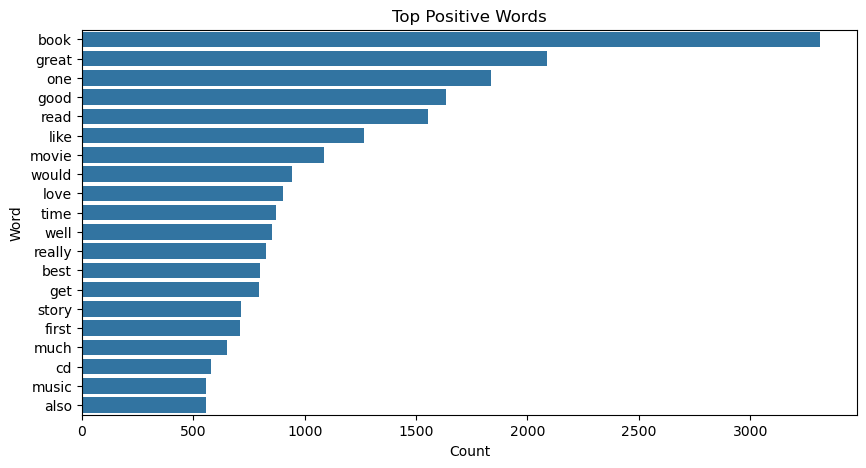

In [21]:
#most common negative words
from collections import Counter

positive_words = " ".join(
    df[df['label']=='pos']['clean_review']
).split()

positive_counts = Counter(positive_words)

top_positive = pd.DataFrame(
    positive_counts.most_common(20),
    columns=['Word','Count']
)

print(top_positive)

plt.figure(figsize=(10,5))
sns.barplot(
    x='Count',
    y='Word',
    data=top_positive
)

plt.title("Top Positive Words")
plt.show()

In [22]:
#convert lables
df['label'] = df['label'].map({
    'pos':1,
    'neg':0
})

df.head()

,label,review,clean_review
0,1,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,1,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hands i...
3,1,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,1,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [23]:
#TF-IDF feature extraction
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

y = df['label']

In [24]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 5000)
(2000, 5000)


In [25]:
#logistic regression model
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

y_pred_lr = lr_model.predict(X_test)

In [26]:
#logistic regression evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.8525
F1 Score: 0.8492590700051099
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1019
           1       0.85      0.85      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



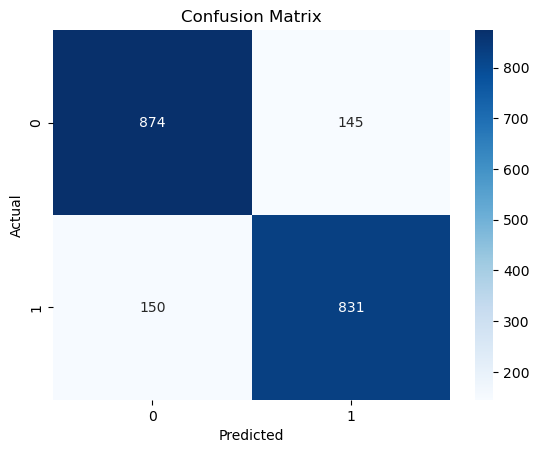

In [27]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
#cross validation
cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Mean Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.8595 0.8335 0.828  0.831  0.849 ]
Mean Accuracy:
0.8402


In [29]:
#svm model
svm_model = LinearSVC()

svm_model.fit(
    X_train,
    y_train
)

y_pred_svm = svm_model.predict(X_test)

In [30]:
#svm evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))

print(classification_report(
    y_test,
    y_pred_svm
))

Accuracy: 0.843
F1 Score: 0.8414141414141414
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1019
           1       0.83      0.85      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [31]:
#model comparison
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_svm)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.8525  0.849259
1                  SVM    0.8430  0.841414


In [32]:
#cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

CV Scores: [0.8595 0.8335 0.828  0.831  0.849 ]
Mean Accuracy: 0.8402


In [33]:
#svm model
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))

print(classification_report(
    y_test,
    y_pred_svm
))

Accuracy: 0.843
F1 Score: 0.8414141414141414
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1019
           1       0.83      0.85      0.84       981

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [34]:
#model comparison
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.8525  0.849259
1                  SVM    0.8430  0.841414


Empty DataFrame
Columns: [Word, Count]
Index: []


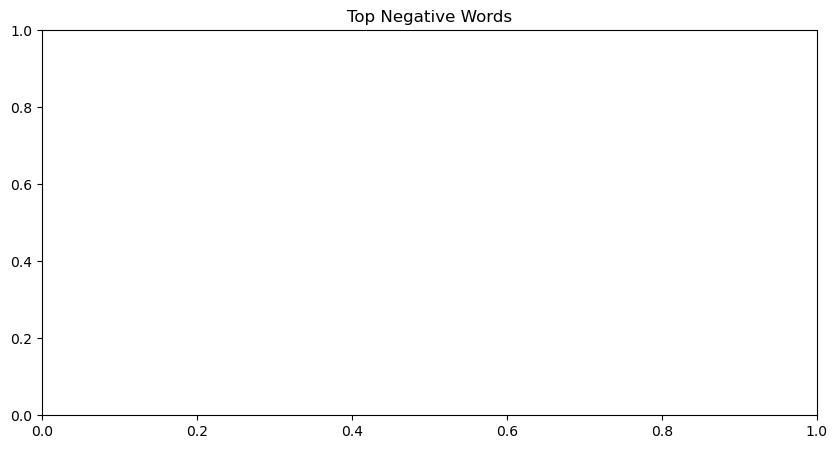

In [35]:
from collections import Counter

negative_words = " ".join(
    df[df['label']=='neg']['clean_review']
).split()

negative_counts = Counter(negative_words)

top_negative = pd.DataFrame(
    negative_counts.most_common(20),
    columns=['Word','Count']
)

print(top_negative)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_negative,
    x='Count',
    y='Word'
)

plt.title("Top Negative Words")
plt.show()